## DBSCAN - Density-Based Spatial Clustering of Applications with Noise
- DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, while marking points that lie alone in low-density regions as outliers.
- It requires two parameters: `eps` (the maximum distance between two samples for them to be considered as in the same neighborhood) and `min_samples` (the number of samples in a neighborhood for a point to be considered as a core point).
- DBSCAN is effective in finding clusters of arbitrary shape and can handle noise in the data, making it suitable for various applications such as spatial data analysis and anomaly detection.

### ADVANTAGES
- DBSCAN does not require one to specify the number of clusters in the data a priori, as opposed to k-means.
- DBSCAN can find arbitrarily-shaped clusters. It can even find a cluster completely surrounded by (but not connected to) a different cluster. Due to the MinPts parameter, the so-called single-link effect (different clusters being connected by a thin line of points) is reduced.
- DBSCAN has a notion of noise, and is robust to outliers.
- DBSCAN requires just two parameters and is mostly insensitive to the ordering of the points in the database. (However, points sitting on the edge of two different clusters might swap cluster membership if the ordering of the points is changed, and the cluster assignment is unique only up to isomorphism.)
- DBSCAN is designed for use with databases that can accelerate region queries, e.g. using an R* tree.
The parameters minPts and ε can be set by a domain expert, if the data is well understood.

### DISADVANTAGES
- DBSCAN is not entirely deterministic: border points that are reachable from more than one cluster can be part of either cluster, depending on the order the data are processed. For most data sets and domains, this situation does not arise often and has little impact on the clustering result:[4] both on core points and noise points, DBSCAN is deterministic. DBSCAN*[6][7] is a variation that treats border points as noise, and this way achieves a fully deterministic result as well as a more consistent statistical interpretation of density-connected components.
- The quality of DBSCAN depends on the distance measure used in the function regionQuery(P,ε). The most common distance metric used is Euclidean distance. Especially for high-dimensional data, this metric can be rendered almost useless due to the so-called "Curse of dimensionality", making it difficult to find an appropriate value for ε. This effect, however, is also present in any other algorithm based on Euclidean distance.
- DBSCAN cannot cluster data sets well with large differences in densities, since the minPts-ε combination cannot then be chosen appropriately for all clusters.[11]
If the data and scale are not well understood, choosing a meaningful distance threshold ε can be difficult.

In [1]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
X, y = make_moons(n_samples=250, noise=0.05)

In [3]:
X

array([[-9.55065868e-01,  4.18240090e-01],
       [-4.70206273e-01,  8.03876848e-01],
       [ 1.66469883e-01, -5.64394365e-02],
       [ 1.16762845e+00, -4.58877863e-01],
       [ 1.11406343e-01, -1.26293881e-01],
       [ 5.26862467e-01, -3.91893248e-01],
       [ 7.89895010e-01,  7.02067181e-01],
       [ 4.14530853e-01,  9.17088896e-01],
       [-1.02648571e+00,  9.12389754e-02],
       [ 1.27967437e+00, -4.68969983e-01],
       [ 1.80907645e+00,  2.54061848e-02],
       [ 1.78569516e+00, -7.54387541e-02],
       [-1.01582794e+00,  1.07638245e-01],
       [-4.95603182e-01,  9.54077031e-01],
       [-6.42342055e-01,  8.32666740e-01],
       [-6.14391856e-01,  6.81005998e-01],
       [ 3.13951260e-02,  4.84156185e-02],
       [ 8.88266677e-01,  4.84655640e-01],
       [-7.59375580e-01,  6.53356781e-01],
       [ 7.94759783e-01, -4.95762185e-01],
       [ 2.47900703e-02,  9.66819704e-01],
       [ 6.28129365e-01,  7.86570246e-01],
       [ 8.67260047e-01, -5.09307055e-01],
       [-9.

In [4]:
y

array([0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 0])

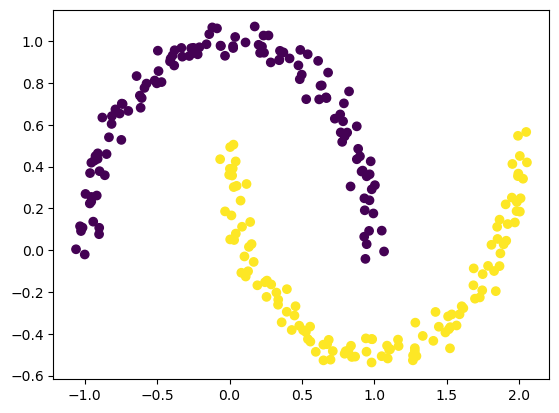

In [5]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [6]:
## Feature Scaling - Standard Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [7]:
X_scaled = scaler.fit_transform(X)

In [8]:
X_scaled

array([[-1.67272479,  0.33325475],
       [-1.11410971,  1.10864594],
       [-0.38058415, -0.62117274],
       [ 0.77286787, -1.43034666],
       [-0.4440238 , -0.7616275 ],
       [ 0.03463035, -1.2956622 ],
       [ 0.33767467,  0.90393952],
       [-0.09478883,  1.33627887],
       [-1.75500882, -0.32423906],
       [ 0.9019579 , -1.45063866],
       [ 1.51189114, -0.45660758],
       [ 1.48495316, -0.65937424],
       [-1.74272981, -0.29126542],
       [-1.14336992,  1.41065008],
       [-1.3124303 ,  1.16653313],
       [-1.2802284 ,  0.86159227],
       [-0.5362061 , -0.41034303],
       [ 0.45101036,  0.46679501],
       [-1.44726664,  0.80599861],
       [ 0.34327946, -1.50450914],
       [-0.5438159 ,  1.43627149],
       [ 0.15130169,  1.07384794],
       [ 0.42680826, -1.53174351],
       [-1.63964436,  0.39684706],
       [-1.72534735, -0.54964453],
       [-1.62155062,  0.42327086],
       [ 1.71297654, -0.03369133],
       [-0.45410184, -0.56854556],
       [ 1.17250775,

In [9]:
dbscan = DBSCAN(eps=0.3)

In [10]:
dbscan.fit(X_scaled)

,eps,0.3
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [11]:
dbscan.labels_

array([0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 0])

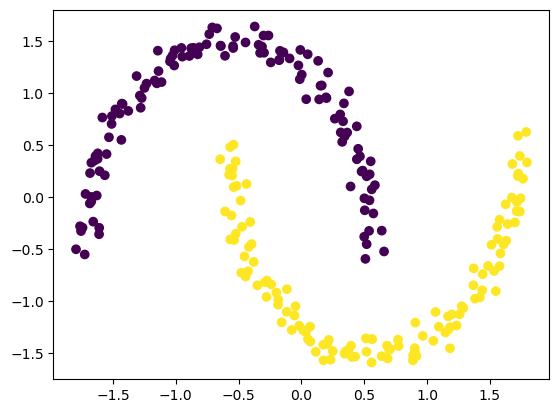

In [12]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan.labels_)